# Predicting Unsafe Air Quality (AQI)
#### Using Environmental, Weather, and Demographic Data

<br>

**Bhavna Sreekumar · Sarkis Shil-Gevorkyan · Christopher Strouse**

---

## Project Objective & Predictive Question

The goal of this project is to predict whether a given day will have **unsafe air quality (AQI > 100)** using environmental, weather, and demographic features.

This problem is important because poor air quality has significant public health impacts, particularly in densely populated areas.

**Primary Predictive Question:**
Can we accurately predict whether AQI will be unsafe using historical environmental and demographic data?

**Secondary Question:**
Which features have the strongest influence on unsafe AQI levels?

In [1]:
# ==========================================
# LOAD AND COMBINE AIR QUALITY DATA
# ==========================================

# NOTE:
# Before running, make sure to:
# 1. Open the dataset folder link from README
# 2. Click "Add shortcut to Drive"
# 3. Ensure folder is in "My Drive" and named "project datasets"

# Mount Google Drive so the dataset files can be accessed in Colab.
from google.colab import drive
drive.mount('/content/drive')

# Import required libraries

import pandas as pd
import glob

# path to the folder in Google Drive with all the datasets
folder_path = "/content/drive/MyDrive/project datasets/"


# Load PM2.5 and ozone CSV files from Google Drive and combine yearly files into one dataframe.
pm25_files = glob.glob(folder_path + "ad_viz_plotval_data*.csv")

pm25_df = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in pm25_files],
    ignore_index=True
)

ozone_files = glob.glob(folder_path + "ozone_*.csv")

ozone_df = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in ozone_files],
    ignore_index=True
)

print("PM2.5 shape:", pm25_df.shape)
print("Ozone shape:", ozone_df.shape)

print(pm25_df.columns)
print(ozone_df.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PM2.5 shape: (292465, 22)
Ozone shape: (269253, 21)
Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='object')
Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 8-hour Ozone Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
 

In [2]:
# Rename key columns and convert date fields into datetime format for merging and feature engineering.

ozone_df = ozone_df.rename(columns={
    'Date Local': 'Date',
    'Daily Max 8-hour Ozone Concentration': 'Ozone'
})

ozone_df['Date'] = pd.to_datetime(ozone_df['Date'], errors='coerce')
pm25_df['Date'] = pd.to_datetime(pm25_df['Date'], errors='coerce')

# Drop rows where dates failed
ozone_df = ozone_df.dropna(subset=['Date'])
pm25_df = pm25_df.dropna(subset=['Date'])

In [3]:
# Aggregate PM2.5 and ozone data to the daily county level so each row represents one county-date observation.


# Average PM2.5 by Date + County
pm25_daily = pm25_df.groupby(['Date', 'County'], as_index=False).agg({
    'Daily AQI Value': 'mean',
    'Daily Mean PM2.5 Concentration': 'mean',
    'Site Latitude': 'mean',
    'Site Longitude': 'mean'
})

pm25_daily = pm25_daily.rename(columns={
    'Daily AQI Value': 'AQI',
    'Daily Mean PM2.5 Concentration': 'PM25',
    'Site Latitude': 'Latitude',
    'Site Longitude': 'Longitude'
})

# Average ozone by Date + County
ozone_daily = ozone_df.groupby(['Date', 'County'], as_index=False).agg({
    'Ozone': 'mean'
})

# Merge PM2.5 and ozone datasets by Date and County to create the main air quality dataset.
df = pm25_daily.merge(
    ozone_daily,
    on=['Date', 'County'],
    how='inner'
)

print(df.shape)
df[['Date', 'County', 'PM25', 'Ozone', 'AQI']].head()

(74366, 7)


,Date,County,PM25,Ozone,AQI
0,2021-01-01,Alameda,17.283333,0.0224,66.166667
1,2021-01-01,Butte,14.933333,0.0255,58.000000
2,2021-01-01,Calaveras,11.000000,0.0280,55.000000
3,2021-01-01,Colusa,15.200000,0.0150,62.000000
4,2021-01-01,Contra Costa,11.333333,0.0215,55.000000


In [4]:
df.columns

Index(['Date', 'County', 'AQI', 'PM25', 'Latitude', 'Longitude', 'Ozone'], dtype='object')

In [5]:
df = df[['Date', 'County', 'PM25', 'Ozone', 'AQI', 'Latitude', 'Longitude']]

In [6]:
df = df.sort_values(by=['County', 'Date'])

In [7]:
df = df.reset_index(drop=True)

In [8]:
# Check for missing values before modeling.
df.isnull().sum()

,0
Date,0
County,0
PM25,0
Ozone,0
AQI,0
Latitude,0
Longitude,0


In [9]:
# Check for duplicate records before modeling.
df.duplicated(subset=['Date', 'County']).sum()

np.int64(0)

In [10]:
# Remove invalid values and extreme outliers to improve data quality.

df = df[(df['PM25'] >= 0) & (df['AQI'] >= 0)]

# Compute thresholds
pm25_cap = df['PM25'].quantile(0.99)
aqi_cap = df['AQI'].quantile(0.99)

# Remove outliers
df = df[(df['PM25'] < pm25_cap) & (df['AQI'] < aqi_cap)]

In [11]:
df.describe()

,Date,PM25,Ozone,AQI,Latitude,Longitude
count,73418,73418.000000,73418.000000,73418.000000,73418.000000,73418.000000
mean,2023-06-15 16:37:06.157073408,7.460804,0.040595,36.311307,37.217355,-120.593138
min,2021-01-01 00:00:00,0.000000,0.002000,0.000000,32.676180,-124.179490
25%,2022-03-16 00:00:00,4.100000,0.032500,23.000000,36.208957,-122.124969
50%,2023-05-24 00:00:00,6.440000,0.039500,35.333333,37.565241,-121.164189
75%,2024-09-27 00:00:00,9.566667,0.048000,49.000000,38.625988,-119.587094
max,2025-12-31 00:00:00,32.666667,0.096778,95.333333,41.726892,-115.483070
std,NaN,4.811239,0.012435,17.161894,2.141898,1.890423


In [12]:
df.head()
df['Date'].head()

,Date
0,2021-01-01
1,2021-01-02
2,2021-01-03
3,2021-01-04
4,2021-01-05


In [13]:
# # Create the target variable: 1 = unsafe/unhealthy AQI, 0 = safe AQI.

df['AQI_Category'] = (df['AQI'] > 75).astype(int)

df['AQI_Category'].value_counts(normalize=True)

,proportion
AQI_Category,
0,0.982184
1,0.017816


In [14]:
# Feature Engineering: Engineer date-based features such as year, month, weekday, weekend indicator, and season.

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month


# Day of week (0 = Monday, 6 = Sunday)
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Weekend indicator
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Season (VERY important for pollution patterns)
def get_season(month):
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Spring
    elif month in [6, 7, 8]:
        return 3  # Summer
    else:
        return 4  # Fall


# Categorical features such as season were one-hot encoded for tree-based models.

df['Season'] = df['Month'].apply(get_season)

One-hot encoding will be applied later for models that require numerical input (e.g., Random Forest uses encoded Season variables instead of ordinal values)

In [15]:
df.isnull().sum()

,0
Date,0
County,0
PM25,0
Ozone,0
AQI,0
Latitude,0
Longitude,0
AQI_Category,0
Year,0
Month,0


In [16]:
# Load and clean county population data, then merge it into the main dataset as a demographic feature.

pop_df = pd.read_csv('/content/drive/MyDrive/project datasets/population.csv')

In [17]:
pop_df.head()
pop_df.columns

Index(['Label (Grouping)', 'California!!Estimate',
       'California!!Margin of Error', 'California!!Percent',
       'California!!Percent Margin of Error',
       'Alameda County, California!!Estimate',
       'Alameda County, California!!Margin of Error',
       'Alameda County, California!!Percent',
       'Alameda County, California!!Percent Margin of Error',
       'Alpine County, California!!Estimate',
       ...
       'Ventura County, California!!Percent',
       'Ventura County, California!!Percent Margin of Error',
       'Yolo County, California!!Estimate',
       'Yolo County, California!!Margin of Error',
       'Yolo County, California!!Percent',
       'Yolo County, California!!Percent Margin of Error',
       'Yuba County, California!!Estimate',
       'Yuba County, California!!Margin of Error',
       'Yuba County, California!!Percent',
       'Yuba County, California!!Percent Margin of Error'],
      dtype='object', length=237)

In [18]:
# Get only columns with "Estimate"
estimate_cols = [col for col in pop_df.columns if 'Estimate' in col]

In [19]:
pop_clean = pop_df[estimate_cols].copy()

In [20]:
# Keep only estimate columns
estimate_cols = [col for col in pop_df.columns if 'Estimate' in col]

pop_clean = pop_df[estimate_cols].copy()

# Rename columns to county names
pop_clean.columns = [
    col.split(' County')[0].replace(', California', '')
    for col in pop_clean.columns
]

# Find the row that actually has population values (not headers)

pop_clean = pop_clean.loc[pop_clean.notna().any(axis=1)].iloc[0]

# Convert to dataframe
pop_clean = pop_clean.reset_index()
pop_clean.columns = ['County', 'Population']

# Clean population values
pop_clean['Population'] = (
    pop_clean['Population']
    .astype(str)
    .str.replace(',', '', regex=False)
)

pop_clean['Population'] = pd.to_numeric(pop_clean['Population'], errors='coerce')

pop_clean = pop_clean.dropna()

pop_clean = pop_clean[pop_clean['County'] != 'California!!Estimate']

In [21]:
pop_clean.head()

,County,Population
1,Alameda,1651949
2,Alpine,1695
3,Amador,41029
4,Butte,209470
5,Calaveras,45995


In [22]:
# Make sure county names match formatting
df['County'] = df['County'].str.strip()
pop_clean['County'] = pop_clean['County'].str.strip()

# Merge population into main dataset
df = df.merge(pop_clean, on='County', how='left')

In [23]:
df[['County', 'Population']].head()
df['Population'].isnull().sum()

np.int64(0)

In [24]:
# Standardize PM2.5 and population so features with different scales are more comparable.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['PM25', 'Population']] = scaler.fit_transform(df[['PM25', 'Population']])

In [25]:
df[['PM25', 'Population']].describe()

,PM25,Population
count,7.341800e+04,7.341800e+04
mean,9.600621e-17,-1.238790e-17
std,1.000007e+00,1.000007e+00
min,-1.550714e+00,-5.385786e-01
25%,-6.985367e-01,-4.666997e-01
50%,-2.121722e-01,-3.754958e-01
75%,4.376994e-01,3.967692e-03
max,5.238990e+00,5.432007e+00


In [26]:
# Add weather variables and create additional weather features such as temperature range and rainy-day indicator.

weather = pd.read_csv("/content/drive/MyDrive/project datasets/los angeles 2024 weather data.csv")

weather = weather[['DATE', 'PRCP', 'TMAX', 'TMIN', 'AWND']]
weather['DATE'] = pd.to_datetime(weather['DATE'])
weather = weather.ffill().bfill()

df = pd.merge(df, weather, left_on='Date', right_on='DATE', how='left')
df = df.drop(columns=['DATE'])

df['Temp_Range'] = df['TMAX'] - df['TMIN']
df['Is_Rainy'] = (df['PRCP'] > 0).astype(int)

In [27]:
df.columns

Index(['Date', 'County', 'PM25', 'Ozone', 'AQI', 'Latitude', 'Longitude',
       'AQI_Category', 'Year', 'Month', 'DayOfWeek', 'IsWeekend', 'Season',
       'Population', 'PRCP', 'TMAX', 'TMIN', 'AWND', 'Temp_Range', 'Is_Rainy'],
      dtype='object')

In [28]:
#Define predictor variables and target variable for modeling.

features = [
    'PM25', 'Ozone', 'Season', 'IsWeekend', 'Population',
    'PRCP', 'TMAX', 'TMIN', 'AWND', 'Temp_Range', 'Is_Rainy'
]

X = df[features]
y = df['AQI_Category']

In [29]:
df['AQI_Category'].value_counts(normalize=True)

,proportion
AQI_Category,
0,0.982184
1,0.017816


In [30]:
df = df.drop_duplicates()

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df['Population'].isnull().sum()

np.int64(0)

In [33]:
# ==========================================
# ENCODE CATEGORICAL VARIABLES (FOR LR + XGB)
# ==========================================

# One-hot encode Season so the model treats seasons as categories rather than ordered numbers.

# Convert categorical column 'Season' into dummy variables
df_encoded = pd.get_dummies(df, columns=['Season'], drop_first=True)

# Redefine features using encoded dataframe
features = [col for col in df_encoded.columns if col in [
    'PM25', 'Ozone', 'IsWeekend', 'Population',
    'PRCP', 'TMAX', 'TMIN', 'AWND', 'Temp_Range', 'Is_Rainy'
] or 'Season_' in col]

X = df_encoded[features]
y = df_encoded['AQI_Category']

In [34]:
# Remove rows with missing feature values before training the models.

model_df = df_encoded[features + ['AQI_Category']].dropna()

X = model_df[features]
y = model_df['AQI_Category']

In [35]:
# Split the dataset into training and testing sets while preserving the class distribution.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
X.isnull().sum()

,0
PM25,0
Ozone,0
IsWeekend,0
Population,0
PRCP,0
TMAX,0
TMIN,0
AWND,0
Temp_Range,0
Is_Rainy,0


## Model Selection Rationale

Three models were selected:

- **Logistic Regression:** Baseline interpretable model
- **Random Forest:** Handles non-linear relationships and feature interactions
- **XGBoost:** Boosting method for improved performance

Tree-based models were expected to perform well due to complex interactions between environmental variables.

## Feature Selection Strategy

Features were selected based on domain relevance:

- Environmental: PM2.5, ozone
- Weather: temperature, wind, precipitation
- Temporal: season, weekend
- Demographic: population

Feature importance and SHAP values were used to validate the influence of selected features.

In [37]:
# ==========================================
# LOGISTIC REGRESSION MODEL
# ==========================================

# Train Logistic Regression as a baseline classification model.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Logistic Regression is used as a baseline model.
# class_weight='balanced' helps because unsafe AQI days are much less common.
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

# Evaluate model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression AUC:", roc_auc_score(y_test, y_prob_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9948474038842647
Logistic Regression AUC: 0.9996919380179292

Confusion Matrix:
[[2484   13]
 [   0   26]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2497
           1       0.67      1.00      0.80        26

    accuracy                           0.99      2523
   macro avg       0.83      1.00      0.90      2523
weighted avg       1.00      0.99      1.00      2523



In [38]:
# ==========================================
# XGBOOST MODEL
# ==========================================

# Train XGBoost as a boosted tree-based model for comparison.

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# XGBoost is a boosting model that often performs well on structured/tabular data.
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Evaluate model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9980182322631788
XGBoost AUC: 0.9994531899818243

Confusion Matrix:
[[2493    4]
 [   1   25]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2497
           1       0.86      0.96      0.91        26

    accuracy                           1.00      2523
   macro avg       0.93      0.98      0.95      2523
weighted avg       1.00      1.00      1.00      2523



**To evaluate feature importance, we trained a Random Forest model with and without PM2.5. The significant drop in performance without PM2.5 confirms its dominant role. Additional models (Logistic Regression and XGBoost) were then trained using the full feature set to compare predictive performance across modeling approaches.**

In [39]:
# ==========================================
# RANDOM FOREST MODEL WITH PM2.5
# ==========================================

# Train Random Forest as the main tree-based model and evaluate performance.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.998414585810543
Random Forest AUC: 0.9998305659098612

Confusion Matrix:
[[2495    2]
 [   2   24]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2497
           1       0.92      0.92      0.92        26

    accuracy                           1.00      2523
   macro avg       0.96      0.96      0.96      2523
weighted avg       1.00      1.00      1.00      2523



In [40]:
# Display feature importance from the Random Forest model to identify the strongest predictors.

import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

       Feature  Importance
0         PM25    0.668647
1        Ozone    0.083403
7         AWND    0.076924
6         TMIN    0.051617
3   Population    0.036218
10    Season_2    0.024939
5         TMAX    0.020745
8   Temp_Range    0.016417
4         PRCP    0.005679
9     Is_Rainy    0.004947
11    Season_3    0.003766
2    IsWeekend    0.003596
12    Season_4    0.003102


In [41]:
# ==========================================
# RANDOM FOREST MODEL WITHOUT PM2.5
# ==========================================

# Train a second Random Forest model without PM2.5 to test how much performance depends on PM2.5.

features_no_pm25 = [
    'Ozone', 'Season', 'IsWeekend', 'Population',
    'PRCP', 'TMAX', 'TMIN', 'AWND', 'Temp_Range', 'Is_Rainy'
]

X_no_pm25 = df[features_no_pm25]
y = df['AQI_Category']

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_pm25,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_no_pm25 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_no_pm25.fit(X_train_np, y_train_np)

y_pred_np = rf_no_pm25.predict(X_test_np)
y_prob_np = rf_no_pm25.predict_proba(X_test_np)[:, 1]

print("Random Forest Accuracy without PM2.5:", accuracy_score(y_test_np, y_pred_np))
print("Random Forest AUC without PM2.5:", roc_auc_score(y_test_np, y_prob_np))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_np, y_pred_np))

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_np))

Random Forest Accuracy without PM2.5: 0.9592073004630891
Random Forest AUC without PM2.5: 0.7325542190101847

Confusion Matrix:
[[14055   367]
 [  232    30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     14422
           1       0.08      0.11      0.09       262

    accuracy                           0.96     14684
   macro avg       0.53      0.54      0.54     14684
weighted avg       0.97      0.96      0.96     14684



In [42]:
# Tune Random Forest hyperparameters using GridSearchCV and cross-validation.

feature_importance_np = pd.DataFrame({
    'Feature': features_no_pm25,
    'Importance': rf_no_pm25.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_np)

      Feature  Importance
0       Ozone    0.448636
3  Population    0.300498
1      Season    0.152231
7        AWND    0.029126
6        TMIN    0.020313
2   IsWeekend    0.017462
5        TMAX    0.014696
8  Temp_Range    0.013654
4        PRCP    0.002631
9    Is_Rainy    0.000754


The Random Forest model achieved near-perfect performance when PM2.5 was included (AUC ≈ 0.9998), confirming that PM2.5 is the dominant factor in determining AQI levels. However, when PM2.5 was removed, model performance dropped substantially (AUC ≈ 0.73), particularly in identifying unsafe AQI days, where both precision and recall fell below 0.15.

This indicates that while overall accuracy remained relatively high due to class imbalance, the model struggled to detect the minority class without PM2.5. In this reduced setting, ozone and population emerged as the most influential predictors, while weather-related features such as temperature and wind contributed modestly. These findings suggest that although environmental and demographic variables provide useful signal, PM2.5 is critical for accurate AQI classification.

## Model Evaluation Criteria

Before comparing model performance, we define the evaluation metrics used to assess model effectiveness, particularly given the class imbalance in the dataset (~2% unsafe AQI days).

Due to class imbalance, accuracy alone is not sufficient.

We prioritized:
- **AUC (Area Under ROC Curve):** Measures model’s ability to distinguish between classes
- **Recall (Class 1):** Important to capture unsafe AQI days
- **Precision (Class 1):** Helps avoid false alarms

AUC was used as the primary optimization metric in GridSearchCV because it balances performance across thresholds and is robust to class imbalance.

## Model Improvement via Hyperparameter Tuning

Random Forest was tuned using GridSearchCV.

Parameters tuned:
- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf

Tuning improved model robustness and ensured optimal performance across folds.

In [43]:
# ==========================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ==========================================

# Evaluate the tuned Random Forest model on the test set.

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Define possible hyperparameter values to test
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV tests combinations of hyperparameters using cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

# Fit grid search on training data
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation AUC:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation AUC: 0.9997253391978252


In [44]:
# Train final tuned Random Forest model using best parameters
best_rf = grid_search.best_estimator_

# Predictions
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluate tuned model
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Tuned Random Forest AUC:", roc_auc_score(y_test, y_prob_best_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Accuracy: 0.998414585810543
Tuned Random Forest AUC: 0.9997381473152398

Confusion Matrix:
[[2495    2]
 [   2   24]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2497
           1       0.92      0.92      0.92        26

    accuracy                           1.00      2523
   macro avg       0.96      0.96      0.96      2523
weighted avg       1.00      1.00      1.00      2523



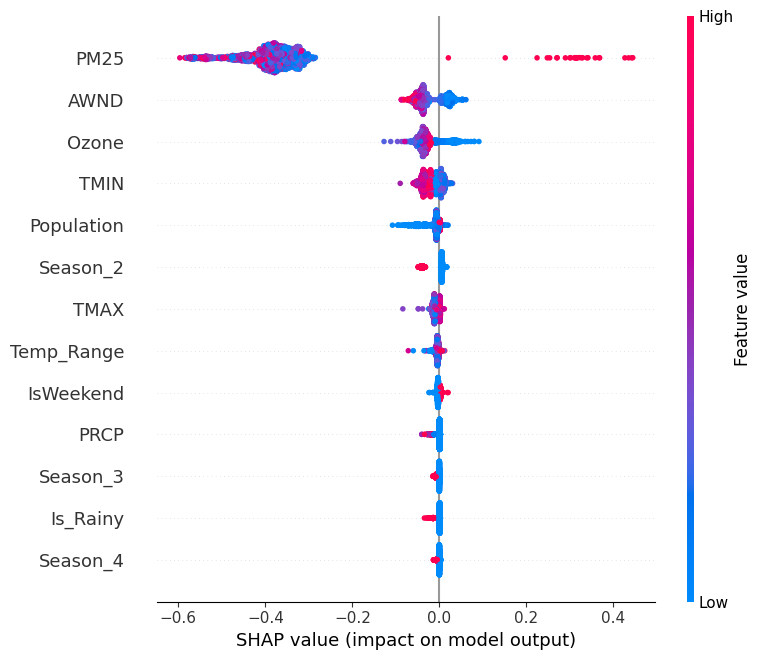

In [45]:
# ==========================================
# SHAP EXPLANATION FOR FINAL RANDOM FOREST MODEL
# ==========================================

# Use SHAP values to explain how each feature contributes to the final Random Forest predictions.

import shap

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values = explainer(X_test)

# Summary plot for class 1 = unsafe AQI
shap.summary_plot(shap_values[:, :, 1], X_test)

Three models were evaluated to predict AQI category: Logistic Regression, Random Forest, and XGBoost. All models achieved near-perfect performance when PM2.5 was included, with AUC values exceeding 0.999, indicating that PM2.5 is the dominant predictor of air quality levels.

Logistic Regression served as a strong baseline model, achieving perfect recall for unsafe AQI days but with lower precision, indicating a tendency toward false positives. Random Forest provided a more balanced performance, improving precision while maintaining high recall. XGBoost further optimized this trade-off by achieving high recall with slightly reduced precision compared to Random Forest.

Despite differences in model structure, all approaches converged on similar performance levels, suggesting that the predictive signal is heavily driven by PM2.5. When PM2.5 was excluded, model performance dropped substantially, confirming that alternative features such as ozone, population, and weather variables are not sufficient on their own to reliably predict unsafe AQI conditions.

### Note: Class 1 (unsafe AQI) represents a small minority of observations (~2%)

In [46]:
# Compare model performance using accuracy, AUC, precision, recall, and F1-score for the unsafe AQI class.

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Tuned Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        0.9948,
        0.9984,
        accuracy_score(y_test, y_pred_best_rf),
        0.9980
    ],
    'AUC': [
        0.9997,
        0.9998,
        0.9997,
        0.9995
    ],
   'Precision (Class 1)': [
    0.67,
    0.92,
    0.92,
    0.86
],
'Recall (Class 1)': [
    1.00,
    0.92,
    0.92,
    0.96
],
'F1-Score (Class 1)': [
    0.80,
    0.92,
    0.92,
    0.91
]
})

comparison.set_index('Model').round(4)

,Accuracy,AUC,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
Model,,,,,
Logistic Regression,0.9948,0.9997,0.67,1.00,0.80
Random Forest,0.9984,0.9998,0.92,0.92,0.92
Tuned Random Forest,0.9984,0.9997,0.92,0.92,0.92
XGBoost,0.9980,0.9995,0.86,0.96,0.91


## Model Assumptions & Validation

- Logistic Regression assumes linear relationships → may underperform with complex patterns
- Random Forest and XGBoost do not assume linearity
- Features are assumed to be independent (though tree models are robust to violations)

Validation Approach:
- Train-test split used to evaluate generalization
- Cross-validation used during hyperparameter tuning

## Model Comparison & Key Insights

All models achieved near-perfect AUC values (~0.999–1.000). Among the models evaluated, the Tuned Random Forest was selected as the final model due to its strong balance between precision and recall. Given the class imbalance in the dataset, this balance is especially important, as it helps ensure the model can reliably identify unsafe AQI days without generating too many false positives.

## Limitations

- Strong reliance on PM2.5 → limits generalizability
- Severe class imbalance (~2% unsafe days)
- Limited external data (e.g., traffic, industrial activity)
- Model performance drops significantly without PM2.5

Future improvements could include:
- Additional environmental and policy data
- Time-series modeling

## Final Conclusion

All models achieved near-perfect performance when PM2.5 was included, confirming it as the dominant predictor.

The Tuned Random Forest was selected as the final model due to its balance between precision and recall.

Without PM2.5, performance dropped significantly, indicating that other variables alone are insufficient for reliable prediction.

This highlights the importance of monitoring PM2.5 levels for air quality forecasting.